In [1]:
#import libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

from sklearn.metrics import mean_absolute_error

In [3]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample = pd.read_csv("sample_submission.csv")

In [4]:
train.head()

,id,clonesize,honeybee,bumbles,andrena,osmia,MaxOfUpperTRange,MinOfUpperTRange,AverageOfUpperTRange,MaxOfLowerTRange,MinOfLowerTRange,AverageOfLowerTRange,RainingDays,AverageRainingDays,fruitset,fruitmass,seeds,yield
0,0,25.0,0.50,0.25,0.75,0.50,69.7,42.1,58.2,50.2,24.3,41.2,24.0,0.39,0.425011,0.417545,32.460887,4476.81146
1,1,25.0,0.50,0.25,0.50,0.50,69.7,42.1,58.2,50.2,24.3,41.2,24.0,0.39,0.444908,0.422051,33.858317,5548.12201
2,2,12.5,0.25,0.25,0.63,0.63,86.0,52.0,71.9,62.0,30.0,50.8,24.0,0.39,0.552927,0.470853,38.341781,6869.77760
3,3,12.5,0.25,0.25,0.63,0.50,77.4,46.8,64.7,55.8,27.0,45.8,24.0,0.39,0.565976,0.478137,39.467561,6880.77590
4,4,25.0,0.50,0.25,0.63,0.63,77.4,46.8,64.7,55.8,27.0,45.8,24.0,0.39,0.579677,0.494165,40.484512,7479.93417


In [5]:
train.shape

(15289, 18)

In [6]:
test.shape

(10194, 17)

In [7]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 15289 entries, 0 to 15288
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    15289 non-null  int64  
 1   clonesize             15289 non-null  float64
 2   honeybee              15289 non-null  float64
 3   bumbles               15289 non-null  float64
 4   andrena               15289 non-null  float64
 5   osmia                 15289 non-null  float64
 6   MaxOfUpperTRange      15289 non-null  float64
 7   MinOfUpperTRange      15289 non-null  float64
 8   AverageOfUpperTRange  15289 non-null  float64
 9   MaxOfLowerTRange      15289 non-null  float64
 10  MinOfLowerTRange      15289 non-null  float64
 11  AverageOfLowerTRange  15289 non-null  float64
 12  RainingDays           15289 non-null  float64
 13  AverageRainingDays    15289 non-null  float64
 14  fruitset              15289 non-null  float64
 15  fruitmass             15289 no

In [8]:
#check for missing values
train.isnull().sum()

id                      0
clonesize               0
honeybee                0
bumbles                 0
andrena                 0
osmia                   0
MaxOfUpperTRange        0
MinOfUpperTRange        0
AverageOfUpperTRange    0
MaxOfLowerTRange        0
MinOfLowerTRange        0
AverageOfLowerTRange    0
RainingDays             0
AverageRainingDays      0
fruitset                0
fruitmass               0
seeds                   0
yield                   0
dtype: int64

In [9]:
test.isnull().sum()

id                      0
clonesize               0
honeybee                0
bumbles                 0
andrena                 0
osmia                   0
MaxOfUpperTRange        0
MinOfUpperTRange        0
AverageOfUpperTRange    0
MaxOfLowerTRange        0
MinOfLowerTRange        0
AverageOfLowerTRange    0
RainingDays             0
AverageRainingDays      0
fruitset                0
fruitmass               0
seeds                   0
dtype: int64

In [10]:
#check for duplicates
train.duplicated().sum()

np.int64(0)

In [11]:
#examine the target variable 
train['yield'].describe()

count    15289.000000
mean      6025.193999
std       1337.056850
min       1945.530610
25%       5128.163510
50%       6117.475900
75%       7019.694380
max       8969.401840
Name: yield, dtype: float64

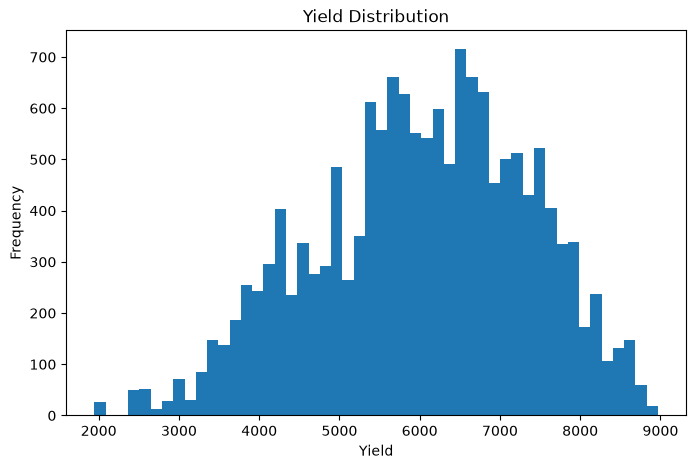

In [13]:
import matplotlib.pyplot as plt

#plotting
plt.figure(figsize=(8,5))
plt.hist(train['yield'], bins=50)
plt.xlabel('Yield')
plt.ylabel('Frequency')
plt.title('Yield Distribution')
plt.show()

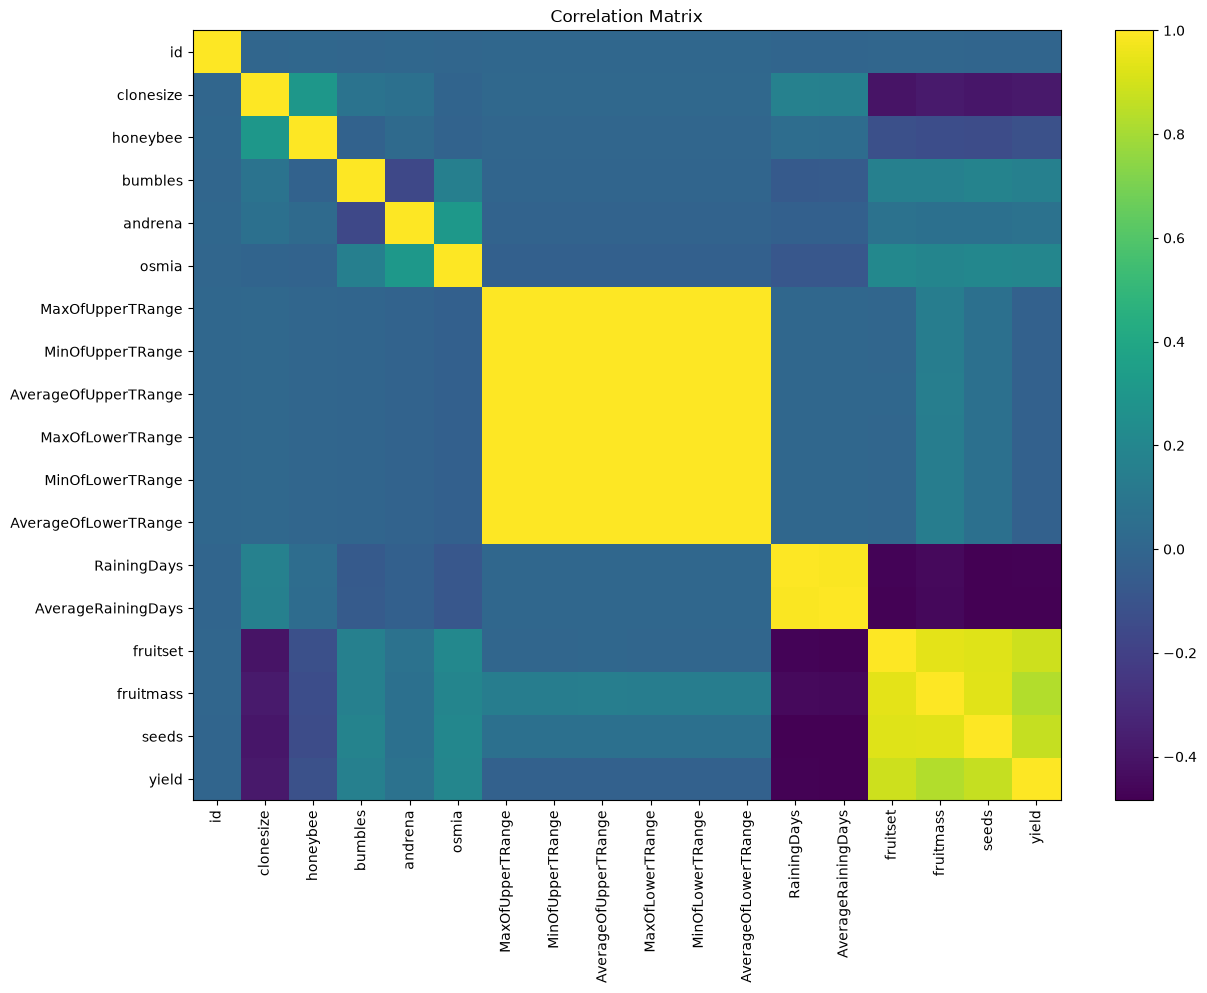

In [14]:
#check coorelations
corr = train.corr(numeric_only=True)

plt.figure(figsize=(14,10))
plt.imshow(corr, aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Correlation Matrix')
plt.show()

In [15]:
#coorelations with yield
train.corr(numeric_only=True)['yield'].sort_values(ascending=False)

yield                   1.000000
fruitset                0.885967
seeds                   0.868853
fruitmass               0.826481
osmia                   0.198264
bumbles                 0.161145
andrena                 0.073969
id                      0.000975
MinOfUpperTRange       -0.021929
AverageOfUpperTRange   -0.021940
AverageOfLowerTRange   -0.022081
MaxOfLowerTRange       -0.022197
MinOfLowerTRange       -0.022319
MaxOfUpperTRange       -0.022517
honeybee               -0.118001
clonesize              -0.382619
RainingDays            -0.477191
AverageRainingDays     -0.483870
Name: yield, dtype: float64

In [16]:
#remove id 
X = train.drop(columns=['yield', 'id'])
y = train['yield']

In [17]:
X_test_final = test.drop(columns=['id'])

In [18]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
#scale the features
scaler = StandardScaler()

In [20]:
#fit transform the training data
X_train_scaled = scaler.fit_transform(X_train)

In [21]:
#transform the validation and test data
X_val_scaled = scaler.transform(X_val)

In [23]:
# Transform the test data using the already-fitted scaler
X_test_final_scaled = scaler.transform(X_test_final)

In [25]:
# The data has already been transformed in previous cells.
X_test_final_scaled

array([[ 0.80843626, -0.38661677, -0.61812629, ..., -1.3936409 ,
        -1.04216613, -1.18644541],
       [-1.09632254, -0.38661677, -0.61812629, ..., -0.20283281,
        -0.10491336,  0.16150396],
       [-1.09632254, -0.38661677, -0.61812629, ...,  1.07727019,
         1.08603739,  0.95031164],
       ...,
       [ 0.80843626,  0.30828629,  1.54924349, ...,  0.8822254 ,
         0.43944806,  0.3785072 ],
       [-1.09632254, -0.38661677, -0.61812629, ..., -1.28612912,
        -1.01056713, -1.06597964],
       [-1.09632254, -0.38661677, -0.61812629, ...,  1.02755853,
         1.06298896,  1.00661992]], shape=(10194, 16))

In [26]:
#train linear regression model
linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](16,)","[ -28.96, -0.32, 19.41,..., 866.99,-269.47, 554.73]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,6030
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,16
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(16)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](16,)","[271.74,219.34,128.93,..., 1.74, 0.65, 0.53]"


In [27]:
linear_pred = linear_model.predict(X_val_scaled)

In [28]:
linear_mae = mean_absolute_error(y_val, linear_pred)

print("Linear Regression MAE:", linear_mae)

Linear Regression MAE: 370.4475274528586


In [29]:
#polynomial regression
PolynomialFeatures(degree=2)

,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'


In [30]:
poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train_scaled)
X_val_poly = poly.transform(X_val_scaled)

In [31]:
poly_model = LinearRegression()

poly_model.fit(X_train_poly, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](152,)","[-60.82, 88.32,-12.08,...,-54.37, 69.86, 91.49]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5977
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,152
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(109)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](152,)","[5090.76, 538.83, 417.3 ,..., 0. , 0. , 0. ]"


In [32]:
poly_pred = poly_model.predict(X_val_poly)

In [33]:
#calculate MAE for polynomial regression
poly_mae = mean_absolute_error(y_val, poly_pred)

print("Polynomial Regression MAE:", poly_mae)

Polynomial Regression MAE: 372.106695907223


In [34]:
#ridge regression
ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_scaled, y_train)

ridge_pred = ridge_model.predict(X_val_scaled)

ridge_mae = mean_absolute_error(y_val, ridge_pred)

print("Ridge MAE:", ridge_mae)

Ridge MAE: 370.7443087818646


In [35]:
#test different alpha values for ridge regression
alphas = [0.01, 0.1, 1, 10, 100]

In [36]:
for alpha in alphas:
    model = Ridge(alpha=alpha)
    model.fit(X_train_scaled, y_train)

    pred = model.predict(X_val_scaled)

    mae = mean_absolute_error(y_val, pred)

    print("Alpha:", alpha, "MAE:", mae)

Alpha: 0.01 MAE: 370.4595830801897
Alpha: 0.1 MAE: 370.5421139255136
Alpha: 1 MAE: 370.7443087818646
Alpha: 10 MAE: 370.8335929337672
Alpha: 100 MAE: 372.0133445227689


In [37]:
#lasso regression
for alpha in alphas:
    model = Ridge(alpha=alpha)
    model.fit(X_train_scaled, y_train)

    pred = model.predict(X_val_scaled)

    mae = mean_absolute_error(y_val, pred)

    print("Alpha:", alpha, "MAE:", mae)

Alpha: 0.01 MAE: 370.4595830801897
Alpha: 0.1 MAE: 370.5421139255136
Alpha: 1 MAE: 370.7443087818646
Alpha: 10 MAE: 370.8335929337672
Alpha: 100 MAE: 372.0133445227689


In [38]:
#test multiple alpha values 
alphas = [0.0001, 0.001, 0.01, 0.1, 1]

In [40]:
for alpha in alphas:
    model = Lasso(alpha=alpha, max_iter=10000)

    model.fit(X_train_scaled, y_train)

    pred = model.predict(X_val_scaled)

    mae = mean_absolute_error(y_val, pred)

    print("Alpha:", alpha, "MAE:", mae)

c:\Users\Nicole Kasiva\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.081556e+09, tolerance: 2.195e+06
  model = cd_fast.enet_coordinate_descent(


Alpha: 0.0001 MAE: 370.8107565498124


c:\Users\Nicole Kasiva\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.029742e+09, tolerance: 2.195e+06
  model = cd_fast.enet_coordinate_descent(


Alpha: 0.001 MAE: 370.8100270616817


c:\Users\Nicole Kasiva\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.545858e+09, tolerance: 2.195e+06
  model = cd_fast.enet_coordinate_descent(


Alpha: 0.01 MAE: 370.8032775465292


c:\Users\Nicole Kasiva\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.746240e+06, tolerance: 2.195e+06
  model = cd_fast.enet_coordinate_descent(


Alpha: 0.1 MAE: 370.76499686176226
Alpha: 1 MAE: 370.6570523111704


In [41]:
#try elastic net regression
elastic_model = ElasticNet(
    alpha=0.001,
    l1_ratio=0.5,
    max_iter=10000
)

elastic_model.fit(X_train_scaled, y_train)

elastic_pred = elastic_model.predict(X_val_scaled)

elastic_mae = mean_absolute_error(y_val, elastic_pred)

print("Elastic Net MAE:", elastic_mae)

Elastic Net MAE: 370.81099129932477


c:\Users\Nicole Kasiva\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.110802e+08, tolerance: 2.195e+06
  model = cd_fast.enet_coordinate_descent(


In [42]:
#test different values
alphas = [0.0001, 0.001, 0.01, 0.1]
l1_ratios = [0.2, 0.5, 0.8]

In [43]:
best_mae = float('inf')
best_alpha = None
best_ratio = None

for alpha in alphas:
    for ratio in l1_ratios:

        model = ElasticNet(
            alpha=alpha,
            l1_ratio=ratio,
            max_iter=10000
        )

        model.fit(X_train_scaled, y_train)

        pred = model.predict(X_val_scaled)

        mae = mean_absolute_error(y_val, pred)

        print(
            "Alpha:", alpha,
            "L1 Ratio:", ratio,
            "MAE:", mae
        )

        if mae < best_mae:
            best_mae = mae
            best_alpha = alpha
            best_ratio = ratio

print("\nBest MAE:", best_mae)
print("Best alpha:", best_alpha)
print("Best l1_ratio:", best_ratio)

c:\Users\Nicole Kasiva\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.084200e+09, tolerance: 2.195e+06
  model = cd_fast.enet_coordinate_descent(


Alpha: 0.0001 L1 Ratio: 0.2 MAE: 370.79734489371475


c:\Users\Nicole Kasiva\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.080503e+09, tolerance: 2.195e+06
  model = cd_fast.enet_coordinate_descent(


Alpha: 0.0001 L1 Ratio: 0.5 MAE: 370.7997007318214


c:\Users\Nicole Kasiva\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.081060e+09, tolerance: 2.195e+06
  model = cd_fast.enet_coordinate_descent(


...

Alpha: 0.001 L1 Ratio: 0.2 MAE: 370.83225484654


c:\Users\Nicole Kasiva\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.110802e+08, tolerance: 2.195e+06
  model = cd_fast.enet_coordinate_descent(


Alpha: 0.001 L1 Ratio: 0.5 MAE: 370.81099129932477


c:\Users\Nicole Kasiva\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.614536e+09, tolerance: 2.195e+06
  model = cd_fast.enet_coordinate_descent(


Alpha: 0.001 L1 Ratio: 0.8 MAE: 370.7968684992702
Alpha: 0.01 L1 Ratio: 0.2 MAE: 371.9760581100842
Alpha: 0.01 L1 Ratio: 0.5 MAE: 371.3860560627021
Alpha: 0.01 L1 Ratio: 0.8 MAE: 370.9501603751493
Alpha: 0.1 L1 Ratio: 0.2 MAE: 390.00478197756644
Alpha: 0.1 L1 Ratio: 0.5 MAE: 383.1303941746353
Alpha: 0.1 L1 Ratio: 0.8 MAE: 375.0169177445355

Best MAE: 370.7968684992702
Best alpha: 0.001
Best l1_ratio: 0.8


In [46]:
lasso_model = Lasso(alpha=0.0001, max_iter=10000)
lasso_model.fit(X_train_scaled, y_train)

lasso_pred = lasso_model.predict(X_val_scaled)
lasso_mae = mean_absolute_error(y_val, lasso_pred)

print("Lasso MAE:", lasso_mae)

Lasso MAE: 370.8107565498124


c:\Users\Nicole Kasiva\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.081556e+09, tolerance: 2.195e+06
  model = cd_fast.enet_coordinate_descent(


In [47]:
#compare models 
# create a results table
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Polynomial Regression',
        'Ridge',
        'Lasso',
        'Elastic Net'
    ],
    'MAE': [
        linear_mae,
        poly_mae,
        ridge_mae,
        lasso_mae,
        elastic_mae
    ]
})

results.sort_values('MAE')

,Model,MAE
0,Linear Regression,370.447527
2,Ridge,370.744309
3,Lasso,370.810757
4,Elastic Net,370.810991
1,Polynomial Regression,372.106696


In [48]:
#ridge regression
alphas = [0.001, 0.01, 0.1, 1, 10, 100]

In [49]:
#lasso regression
alphas = [0.0001, 0.001, 0.01, 0.1, 1]

In [50]:
#elastic net
alphas = [0.0001, 0.001, 0.01, 0.1, 1]

In [51]:
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]

In [52]:
#polynomial degrees
degrees = [2, 3]

In [53]:
for degree in [2, 3]:

    poly = PolynomialFeatures(
        degree=degree,
        include_bias=False
    )

    X_train_poly = poly.fit_transform(X_train_scaled)
    X_val_poly = poly.transform(X_val_scaled)

    model = Ridge(alpha=1.0)

    model.fit(X_train_poly, y_train)

    pred = model.predict(X_val_poly)

    mae = mean_absolute_error(y_val, pred)

    print("Degree:", degree)
    print("MAE:", mae)

Degree: 2
MAE: 368.731000263261
Degree: 3
MAE: 613.7119351845054


In [54]:
final_scaler = StandardScaler()

X_scaled = final_scaler.fit_transform(X)
X_test_scaled = final_scaler.transform(X_test_final)